# Análise Estrutural de Grafos — Parte III

Este notebook responde às questões da **Parte III** da atividade:
1. Small-World (propriedade)
2. Lei de Potência na distribuição de graus
3. Robustez a remoções
4. Descoberta mais interessante

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import random
import math
from collections import Counter

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

Bibliotecas carregadas com sucesso!


/home/estrela/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv("grafo_sem_tempo.csv")
print(f"Linhas no CSV (arestas): {len(df):,}")
print(df.head())

G = nx.from_pandas_edgelist(df, source='source', target='target', edge_attr='weight')

n = G.number_of_nodes()
m = G.number_of_edges()
avg_k = 2 * m / n
density = 2 * m / (n * (n - 1))

print(f"\n{'='*45}")
print(f"  Nós (vértices):          {n:>8,}")
print(f"  Arestas:                 {m:>8,}")
print(f"  Grau médio ⟨k⟩:          {avg_k:>8.2f}")
print(f"  Densidade:               {density:>8.6f}")
print(f"  Componentes conexas:     {nx.number_connected_components(G):>8}")
print(f"{'='*45}")

# Usar maior componente conexa para métricas de caminho
largest_cc = max(nx.connected_components(G), key=len)
G_cc = G.subgraph(largest_cc).copy()
print(f"\nMaior componente conexa: {G_cc.number_of_nodes():,} nós, {G_cc.number_of_edges():,} arestas")

Linhas no CSV (arestas): 24,186
   source  target  weight
0    7188       1      10
1     430       1      10
2    3134       1      10
3    3026       1      10
4    3010       1      10

  Nós (vértices):             3,783
  Arestas:                   14,124
  Grau médio ⟨k⟩:              7.47
  Densidade:               0.001974
  Componentes conexas:            5

Maior componente conexa: 3,775 nós, 14,120 arestas


In [3]:
# SMALL-WORLD?
# ── Coeficiente de clustering real ──────────────────────────
C_real = nx.average_clustering(G_cc)
print(f"C_real (clustering médio):  {C_real:.4f}")

# ── Caminho médio — estimativa por amostragem ──────────────
# Calculamos a distância média a partir de uma amostra de nós raiz
# para evitar O(n²) sobre o grafo completo.
random.seed(42)
sample = random.sample(list(G_cc.nodes()), 300)
total_len, count = 0, 0
for src in sample:
    lengths = nx.single_source_shortest_path_length(G_cc, src)
    for tgt, l in lengths.items():
        if tgt != src:
            total_len += l
            count += 1
L_real = total_len / count
print(f"L_real (caminho médio, amostra 300 nós): {L_real:.4f}")

# ── Baseline Erdős–Rényi ───────────────────────────────────
n_cc = G_cc.number_of_nodes()
m_cc = G_cc.number_of_edges()
avg_k_cc = 2 * m_cc / n_cc
p_er = 2 * m_cc / (n_cc * (n_cc - 1))

# Approx: L_rand ≈ ln(n) / ln(⟨k⟩)
L_rand = math.log(n_cc) / math.log(avg_k_cc)
# C_rand = p (probabilidade de aresta)
C_rand = p_er

print(f"\nBaseline Erdős–Rényi (n={n_cc}, ⟨k⟩={avg_k_cc:.2f}):")
print(f"  L_rand ≈ {L_rand:.4f}")
print(f"  C_rand = {C_rand:.6f}")

# ── Índice sigma ──────────────────────────────────────────
sigma = (C_real / C_rand) / (L_real / L_rand)
print(f"\n{'='*40}")
print(f"  σ (sigma) = {sigma:.2f}")
print(f"  C_real / C_rand = {C_real/C_rand:.1f}×")
print(f"  L_real / L_rand = {L_real/L_rand:.2f}×")
print(f"{'='*40}")
print(f"\n→ σ >> 1 confirma propriedade SMALL-WORLD ✓" if sigma > 1 else "→ Não satisfaz small-world")

C_real (clustering médio):  0.1770
L_real (caminho médio, amostra 300 nós): 3.5596

Baseline Erdős–Rényi (n=3775, ⟨k⟩=7.48):
  L_rand ≈ 4.0928
  C_rand = 0.001982

  σ (sigma) = 102.67
  C_real / C_rand = 89.3×
  L_real / L_rand = 0.87×

→ σ >> 1 confirma propriedade SMALL-WORLD ✓


Expoente γ (inclinação negativa): 1.384
R² do ajuste log-log:             0.8576

→ γ = 1.38 → afasta-se da faixa típica [2,3]


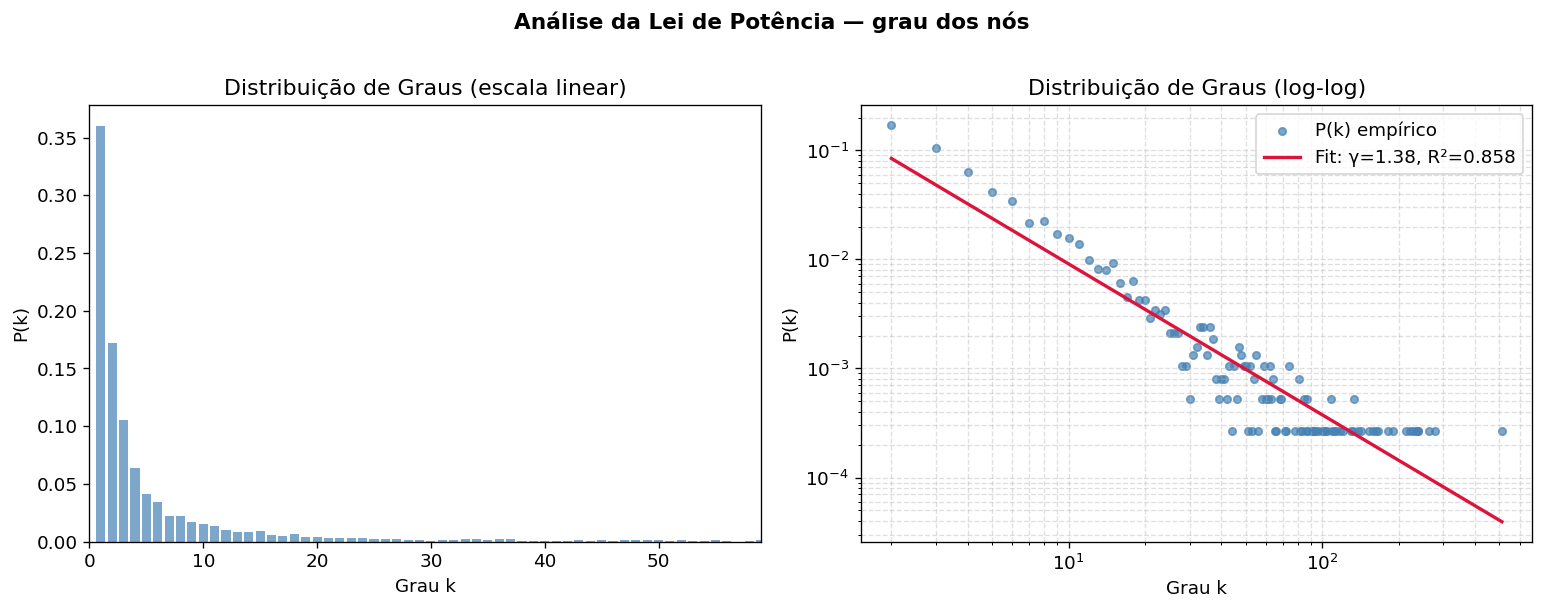

Figura salva: degree_distribution.png


In [4]:
# ── Distribuição de graus ─────────────────────────────────
degrees = np.array([d for _, d in G_cc.degree()])
deg_cnt = Counter(degrees)
ks = np.array(sorted(deg_cnt.keys()))
pk = np.array([deg_cnt[k] for k in ks], dtype=float) / len(degrees)

# ── Regressão log-log (manual, sem scipy) ─────────────────
# Usamos apenas k >= 2 para evitar distorção em k=1
mask = ks >= 2
log_k = np.log(ks[mask])
log_p = np.log(pk[mask])

# Mínimos Quadrados: y = a + b*x
n_pts = len(log_k)
b = (n_pts * np.sum(log_k * log_p) - np.sum(log_k) * np.sum(log_p)) /     (n_pts * np.sum(log_k**2) - np.sum(log_k)**2)
a = (np.sum(log_p) - b * np.sum(log_k)) / n_pts

gamma = -b
log_p_pred = a + b * log_k
SS_res = np.sum((log_p - log_p_pred)**2)
SS_tot = np.sum((log_p - np.mean(log_p))**2)
R2 = 1 - SS_res / SS_tot

print(f"Expoente γ (inclinação negativa): {gamma:.3f}")
print(f"R² do ajuste log-log:             {R2:.4f}")
print(f"\n→ γ = {gamma:.2f} {'→ compatível com lei de potência (2 ≤ γ ≤ 3)' if 1.5 <= gamma <= 4 else '→ afasta-se da faixa típica [2,3]'}")

# ── Gráfico ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Escala normal
axes[0].bar(ks, pk, color='steelblue', alpha=0.7, width=0.8)
axes[0].set_title("Distribuição de Graus (escala linear)")
axes[0].set_xlabel("Grau k")
axes[0].set_ylabel("P(k)")
axes[0].set_xlim(0, np.percentile(degrees, 98))

# Log-log com fit
axes[1].scatter(ks[mask], pk[mask], color='steelblue', s=20, alpha=0.7, label='P(k) empírico')
k_fit = np.linspace(log_k.min(), log_k.max(), 100)
axes[1].plot(np.exp(k_fit), np.exp(a + b * k_fit),
             color='crimson', linewidth=2, label=f'Fit: γ={gamma:.2f}, R²={R2:.3f}')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title("Distribuição de Graus (log-log)")
axes[1].set_xlabel("Grau k")
axes[1].set_ylabel("P(k)")
axes[1].legend()
axes[1].grid(True, which='both', linestyle='--', alpha=0.4)

plt.suptitle("Análise da Lei de Potência — grau dos nós", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("degree_distribution.png", bbox_inches='tight')
plt.show()
print("Figura salva: degree_distribution.png")

Nós na GCC original: 3775
5% dos nós = 188 nós a remover

(a) Após remoção ALEATÓRIA de 188 nós:
    GCC restante: 3398 nós (90.0% do original)

Calculando betweenness centrality (k=300 amostras)...

(b) Após remoção dos 188 nós MAIS CENTRAIS:
    GCC restante: 2219 nós (58.8% do original)


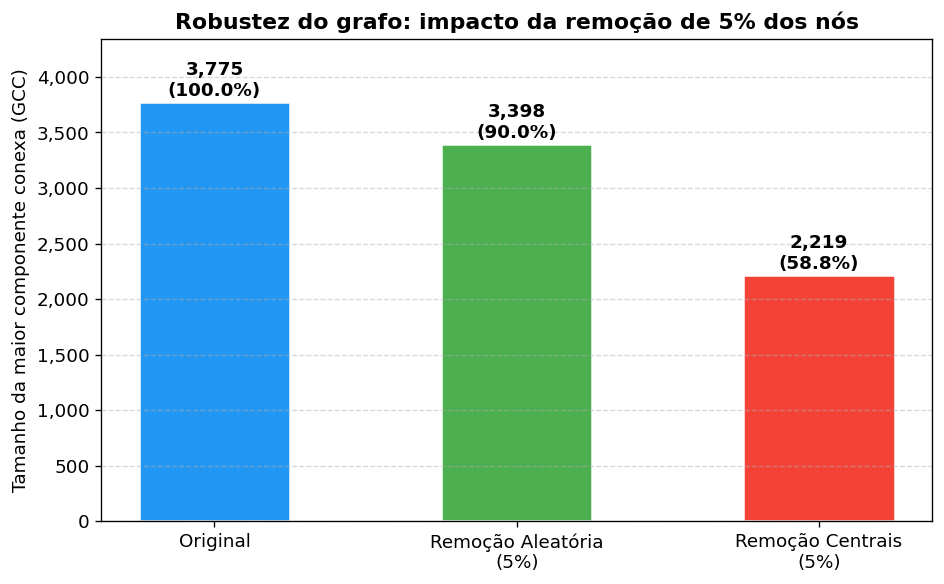

Figura salva: robustez.png


In [5]:
# ── Parâmetros ────────────────────────────────────────────
frac = 0.05
n_remove = int(frac * G_cc.number_of_nodes())
print(f"Nós na GCC original: {G_cc.number_of_nodes()}")
print(f"5% dos nós = {n_remove} nós a remover")

# ─── (a) Remoção aleatória ─────────────────────────────────
random.seed(123)
random_nodes = random.sample(list(G_cc.nodes()), n_remove)
G_rand = G_cc.copy()
G_rand.remove_nodes_from(random_nodes)

gcc_rand = max(nx.connected_components(G_rand), key=len)
size_rand = len(gcc_rand)
ratio_rand = size_rand / G_cc.number_of_nodes()

print(f"\n(a) Após remoção ALEATÓRIA de {n_remove} nós:")
print(f"    GCC restante: {size_rand} nós ({ratio_rand:.1%} do original)")

# ─── (b) Remoção dos mais centrais ────────────────────────
print("\nCalculando betweenness centrality (k=300 amostras)...")
bc = nx.betweenness_centrality(G_cc, normalized=True, k=300, seed=42)
top_bc_nodes = sorted(bc, key=bc.get, reverse=True)[:n_remove]

G_targ = G_cc.copy()
G_targ.remove_nodes_from(top_bc_nodes)

gcc_targ = max(nx.connected_components(G_targ), key=len)
size_targ = len(gcc_targ)
ratio_targ = size_targ / G_cc.number_of_nodes()

print(f"\n(b) Após remoção dos {n_remove} nós MAIS CENTRAIS:")
print(f"    GCC restante: {size_targ} nós ({ratio_targ:.1%} do original)")

# ── Comparação visual ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
categorias = ['Original', 'Remoção Aleatória\n(5%)', 'Remoção Centrais\n(5%)']
valores    = [G_cc.number_of_nodes(), size_rand, size_targ]
cores      = ['#2196F3', '#4CAF50', '#F44336']

bars = ax.bar(categorias, valores, color=cores, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}\n({val/G_cc.number_of_nodes():.1%})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel("Tamanho da maior componente conexa (GCC)")
ax.set_title("Robustez do grafo: impacto da remoção de 5% dos nós", fontweight='bold')
ax.set_ylim(0, G_cc.number_of_nodes() * 1.15)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("robustez.png", bbox_inches='tight')
plt.show()
print("Figura salva: robustez.png")

    Nó     Grau    BC (norm)  % BC global
------------------------------------------
     1      511       0.1961       19.61%
     8      279       0.0593        5.93%
     3      263       0.0478        4.78%
     2      239       0.0768        7.68%
    11      238       0.0594        5.94%
     7      234       0.0337        3.37%
   177      229       0.0326        3.26%
     4      221       0.0623        6.23%
    15      213       0.0504        5.04%
     5      190       0.0487        4.87%

Top 1% dos nós (37 nós) detêm 20.9% das arestas


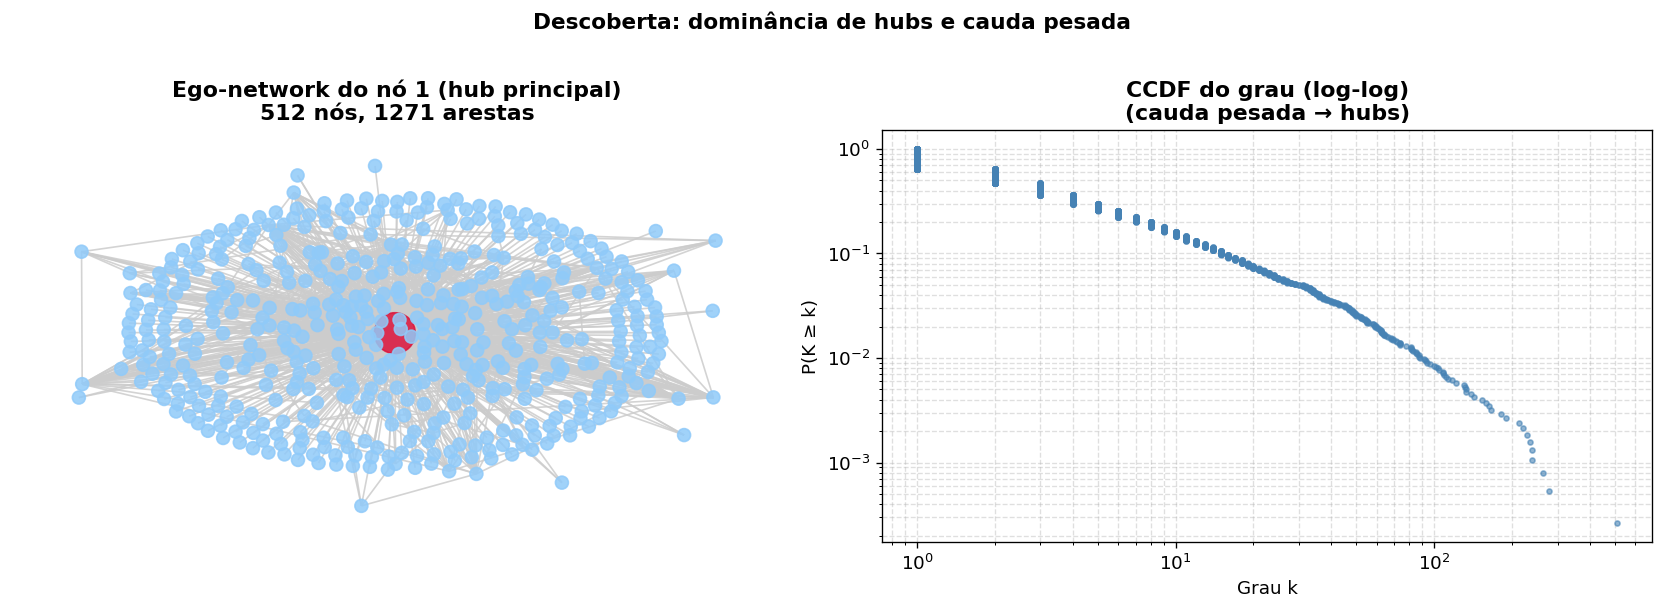

Figura salva: descoberta.png


In [6]:
# ── Top hubs e suas propriedades ────────────────────────────
degrees_dict = dict(G_cc.degree())
bc_full = nx.betweenness_centrality(G_cc, normalized=True, k=500, seed=42)

top_n = 10
top_nodes = sorted(degrees_dict, key=degrees_dict.get, reverse=True)[:top_n]

print(f"{'Nó':>6} {'Grau':>8} {'BC (norm)':>12} {'% BC global':>12}")
print("-" * 42)
for nd in top_nodes:
    print(f"{nd:>6} {degrees_dict[nd]:>8} {bc_full[nd]:>12.4f} {bc_full[nd]*100:>11.2f}%")

# Concentração: top 1% dos nós → % das arestas
top1pct = int(0.01 * G_cc.number_of_nodes())
top_by_deg = sorted(degrees_dict, key=degrees_dict.get, reverse=True)[:top1pct]
edges_top = sum(degrees_dict[nd] for nd in top_by_deg) / 2
total_edges = G_cc.number_of_edges()
print(f"\nTop 1% dos nós ({top1pct} nós) detêm {edges_top/total_edges:.1%} das arestas")

# ── Visualização: Ego-network do nó 1 ──────────────────────
ego = nx.ego_graph(G_cc, 1, radius=1)
pos_ego = nx.spring_layout(ego, seed=42, k=0.3)

node_colors = ['crimson' if nd == 1 else '#90CAF9' for nd in ego.nodes()]
node_sizes  = [600 if nd == 1 else 60 for nd in ego.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ego-graph
nx.draw_networkx(ego, pos=pos_ego, ax=axes[0],
                 node_color=node_colors, node_size=node_sizes,
                 with_labels=False, edge_color='#cccccc', alpha=0.85)
axes[0].set_title(f"Ego-network do nó 1 (hub principal)\n{ego.number_of_nodes()} nós, {ego.number_of_edges()} arestas", fontweight='bold')
axes[0].axis('off')

# CCDF do grau
sorted_deg = np.sort(list(degrees_dict.values()))[::-1]
ccdf = np.arange(1, len(sorted_deg)+1) / len(sorted_deg)
axes[1].loglog(sorted_deg, ccdf, 'o', markersize=3, color='steelblue', alpha=0.6)
axes[1].set_xlabel("Grau k")
axes[1].set_ylabel("P(K ≥ k)")
axes[1].set_title("CCDF do grau (log-log)\n(cauda pesada → hubs)", fontweight='bold')
axes[1].grid(True, which='both', linestyle='--', alpha=0.4)

plt.suptitle("Descoberta: dominância de hubs e cauda pesada", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("descoberta.png", bbox_inches='tight')
plt.show()
print("Figura salva: descoberta.png")